# Homework 2: The Bell Basis

### Instructions:
Just like last week, run each block sequentially from the top to load the libraries and constuct the first circuit. After the Problem 3 header below, you have some of your own coding to do to construct three more circuits, which is the actual assignment task. When you are done, attach a pdf of the entire completed notebook to your homework submission.

In [1]:
#Setup for Qiskit

import qiskit
from qiskit import *
import numpy as np
from qiskit import QuantumCircuit, transpile, assemble, Aer, IBMQ, execute
from qiskit.visualization import plot_histogram, plot_bloch_vector, plot_bloch_multivector, array_to_latex
from qiskit.quantum_info import Statevector
import matplotlib

Recall that the Hadamard gate maps the computational basis to 

$$ \hat{H} |0\rangle = \frac{1}{\sqrt{2}} (|0\rangle + |1\rangle)$$
$$ \hat{H} |1\rangle = \frac{1}{\sqrt{2}} (|0\rangle - |1\rangle).$$

Also, remember from last week that to generate $|\Phi^+ \rangle = \frac{1}{\sqrt{2}} (|00\rangle + | 11 \rangle)$ from the computational basis we apply the following gates to the $|00 \rangle$ state;

$$(CNOT_{01})(\hat{H} \otimes \hat{I}) |00\rangle = \frac{1}{\sqrt{2}} (|00\rangle + | 11 \rangle)$$

Let's construct the circuit. In circuit form, we have

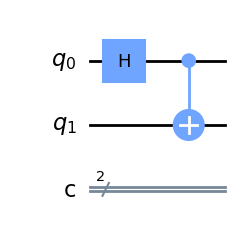

In [2]:
n=2 # define the number of qubits

q=QuantumRegister(2,"q") # initialize a circuit with two qubits in the |0> state
c=ClassicalRegister(2,"c") # create two classical registers in case we want to measure our qubits

circuit=QuantumCircuit(q,c) # define the quantum circuit

circuit.h(q[0]) # apply a Hadamard operation to the zeroth qubit
circuit.cx(q[0],q[1]) # apply a controlled-NOT operation using the zeroth qubit as the control

circuit.draw(output="mpl") # draw circuit

In [3]:
n=2

q=QuantumRegister(2,"q")
c=ClassicalRegister(2,"c")

circuit=QuantumCircuit(q,c)

circuit.h(q[0])
circuit.cx(q[0],q[1])

backend = Aer.get_backend('statevector_simulator') # exactly simulates the evolution of the state starting in |00>
shots = 1 # simulate once
result=execute(circuit, backend=backend, shots=shots).result() # run simulation
statevector=result.get_statevector() # store the output statevector
print(statevector)

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


By inspecting the statevector, we see that this circuit indeed created

$$| \Phi^+ \rangle = \frac{1}{\sqrt{2}} (|00\rangle + | 11 \rangle) = \begin{pmatrix} \frac{1}{\sqrt{2}} \\ 0 \\ 0 \\ \frac{1}{\sqrt{2}}\end{pmatrix}. $$


# Problem 3

Your task is to modify the code above to create the circuits which generate the remaining three states of the Bell basis. The Bell basis is a set of four maximally entangled states of two qubits given as

$$|\Phi^+ \rangle = \frac{1}{\sqrt{2}} (|00\rangle + | 11 \rangle),$$
$$|\Phi^- \rangle = \frac{1}{\sqrt{2}} (|00\rangle - | 11 \rangle),$$
$$|\Psi^+ \rangle = \frac{1}{\sqrt{2}} (|01\rangle + | 10 \rangle),$$
$$|\Psi^- \rangle = \frac{1}{\sqrt{2}} (|01\rangle - | 10 \rangle).$$
The Bell states are discussed on Page 136 and 137 of the textbook, where example circuits are given. 

Your code goes below:

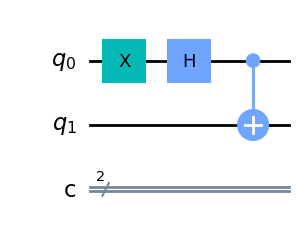

In [4]:
#Drawing the Phi- bell state
n=2 # define the number of qubits

q=QuantumRegister(n,"q") # initialize a circuit with two qubits in the |0> state
c=ClassicalRegister(n,"c") # create two classical registers in case we want to measure our qubits

circuit=QuantumCircuit(q,c) # define the quantum circuit

circuit.x(q[0]) # apply a X gate to the zeroth qubit
circuit.h(q[0]) # apply a Hadamard operation to the zeroth qubit
circuit.cx(q[0],q[1]) # apply a controlled-NOT operation using the zeroth qubit as the control

circuit.draw(output="mpl") # draw circuit

In [5]:
#Computing Phi- bell state
backend = Aer.get_backend('statevector_simulator') # exactly simulates the evolution of the state starting in |00>
shots = 1 # simulate once
result=execute(circuit, backend=backend, shots=shots).result() # run simulation
statevector=result.get_statevector() # store the output statevector
print("For Phi-", statevector)

For Phi- Statevector([ 0.70710678+0.00000000e+00j,  0.        +0.00000000e+00j,
              0.        +0.00000000e+00j, -0.70710678-8.65956056e-17j],
            dims=(2, 2))


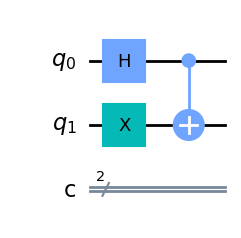

In [6]:
#Drawing the Psi+ bell state
n=2 # define the number of qubits

q=QuantumRegister(n,"q") # initialize a circuit with two qubits in the |0> state
c=ClassicalRegister(n,"c") # create two classical registers in case we want to measure our qubits

circuit=QuantumCircuit(q,c) # define the quantum circuit

circuit.x(q[1]) # apply a X gate to the zeroth qubit
circuit.h(q[0]) # apply a Hadamard operation to the zeroth qubit
circuit.cx(q[0],q[1]) # apply a controlled-NOT operation using the zeroth qubit as the control

circuit.draw(output="mpl") # draw circuit

In [7]:
#Computing Psi+ bell state
backend = Aer.get_backend('statevector_simulator') # exactly simulates the evolution of the state starting in |00>
shots = 1 # simulate once
result=execute(circuit, backend=backend, shots=shots).result() # run simulation
statevector=result.get_statevector() # store the output statevector
print("For Psi+", statevector)

For Psi+ Statevector([0.        +0.j, 0.70710678+0.j, 0.70710678+0.j,
             0.        +0.j],
            dims=(2, 2))


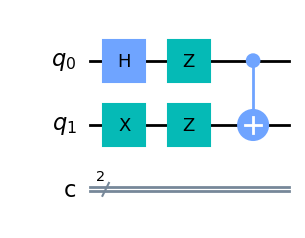

In [8]:
#Drawing the Psi- bell state
n=2 # define the number of qubits

q=QuantumRegister(n,"q") # initialize a circuit with two qubits in the |0> state
c=ClassicalRegister(n,"c") # create two classical registers in case we want to measure our qubits

circuit=QuantumCircuit(q,c) # define the quantum circuit

circuit.x(q[1]) # apply a X gate to the zeroth qubit
circuit.h(q[0]) # apply a Hadamard operation to the zeroth qubit
circuit.z(q[0]) # apply a X gate to the zeroth qubit
circuit.z(q[1]) # apply a X gate to the zeroth qubit
circuit.cx(q[0],q[1]) # apply a controlled-NOT operation using the zeroth qubit as the control

circuit.draw(output="mpl") # draw circuit

In [9]:
#Computing Psi- bell state
backend = Aer.get_backend('statevector_simulator') # exactly simulates the evolution of the state starting in |00>
shots = 1 # simulate once
result=execute(circuit, backend=backend, shots=shots).result() # run simulation
statevector=result.get_statevector() # store the output statevector
print("For Psi-", statevector)

For Psi- Statevector([-4.32978028e-17+5.30245156e-33j,
              7.07106781e-01+0.00000000e+00j,
             -7.07106781e-01+8.65956056e-17j,
              4.32978028e-17+0.00000000e+00j],
            dims=(2, 2))
